In [1]:
import numpy as np
import pandas as pd

import torch

import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
import cv2
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import seaborn as sns

print("Thư viện đã import thành công!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Thư viện đã import thành công!
PyTorch version: 2.6.0+cu124
CUDA available: True


In [2]:
path_local = '/kaggle/input/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof'
path_lcc = '/kaggle/input/lcc-fasd/LCC_FASD'
casia_path = '/kaggle/input/casia-fasd/casia-fasd'

IMG_SHAPE = (224, 224, 3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} - {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Device: cuda - Tesla P100-PCIE-16GB


In [3]:
path_train_json = '/kaggle/input/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/train_label.json'
path_test_json  = '/kaggle/input/celeba-spoof-for-face-antispoofing/CelebA_Spoof_/CelebA_Spoof/metas/intra_test/test_label.json'

df_train = pd.read_json(path_train_json, orient='index')
df_test  = pd.read_json(path_test_json,  orient='index')
df_train.columns = [f'C{i}' for i in range(44)]
df_test.columns  = [f'C{i}' for i in range(44)]

# Cân bằng CelebA train/test
live_train  = df_train[df_train['C40'] == 0].sample(35547, random_state=42)
spoof_train = df_train[df_train['C40'] == 1].sample(35547, random_state=42)
df_train_bal = pd.concat([live_train, spoof_train]).sample(frac=1).reset_index()

live_test  = df_test[df_test['C40'] == 0].sample(3600, random_state=42)
spoof_test = df_test[df_test['C40'] == 1].sample(3600, random_state=42)
df_test_bal = pd.concat([live_test, spoof_test]).sample(frac=1).reset_index()

# Map nhãn: live=1, spoof=0
df_train_bal['C40'] = df_train_bal['C40'].map({0: 1, 1: 0})
df_test_bal['C40']  = df_test_bal['C40'].map({0: 1, 1: 0})

df_train_bal = df_train_bal[['index', 'C40']].rename(columns={'index': 'path', 'C40': 'label'})
df_test_bal  = df_test_bal[['index', 'C40']].rename(columns={'index': 'path', 'C40': 'label'})

df_train_bal['path'] = df_train_bal['path'].apply(lambda x: os.path.join(path_local, x))
df_test_bal['path']  = df_test_bal['path'].apply(lambda x: os.path.join(path_local, x))

print(f"CelebA train: {len(df_train_bal)} | test: {len(df_test_bal)}")
df_train_final = df_train_bal.copy()
print(f"Tập train ban đầu (CelebA balanced): {len(df_train_final):,} ảnh")
print("Phân bố nhãn:", df_train_final['label'].value_counts().to_dict())

CelebA train: 71094 | test: 7200
Tập train ban đầu (CelebA balanced): 71,094 ảnh
Phân bố nhãn: {0: 35547, 1: 35547}


In [4]:
def add_casia_specific(split): 
    data = []
    for label_name, label in [('live', 1), ('spoof', 0)]:
        folder = os.path.join(casia_path, split, label_name)
        if not os.path.exists(folder):
            print(f"Không tìm thấy folder: {folder}")
            continue
        files = [f for f in os.listdir(folder) if not f.startswith('.') and f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"  → CASIA/{split}/{label_name}: {len(files)} ảnh")
        for file in files:
            full_path = os.path.join(folder, file)
            data.append({'path': full_path, 'label': label})
    return pd.DataFrame(data)

print("Đang thêm CASIA-FASD (chỉ train split) vào training...")
df_casia_train = add_casia_specific('train')
print(f"\nCASIA-FASD train thêm: {len(df_casia_train)} ảnh")
print("Live / Spoof:", df_casia_train['label'].value_counts().to_dict())

df_train_final = pd.concat([df_train_final, df_casia_train], ignore_index=True)
df_train_final = df_train_final.sample(frac=1, random_state=42).reset_index(drop=True)


print(f"\nTổng train sau thêm CASIA: {len(df_train_final):,} ảnh")
print(df_train_final['label'].value_counts())

Đang thêm CASIA-FASD (chỉ train split) vào training...
  → CASIA/train/live: 19011 ảnh
  → CASIA/train/spoof: 38736 ảnh

CASIA-FASD train thêm: 57747 ảnh
Live / Spoof: {0: 38736, 1: 19011}

Tổng train sau thêm CASIA: 128,841 ảnh
label
0    74283
1    54558
Name: count, dtype: int64


In [5]:
print("Đang thêm LCC_FASD (chỉ training split)...")

def add_lcc_training_only():
    data = []
    folders = [('real', 1), ('spoof', 0)]
    base_path = os.path.join(path_lcc, 'LCC_FASD_training')
    if not os.path.exists(base_path):
        print(f"Không tìm thấy: {base_path}")
        return pd.DataFrame(data)
    
    for folder_name, label in folders:
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            continue
        files = [f for f in os.listdir(folder_path) if not f.startswith('.') and f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
        print(f"  → LCC_FASD_training/{folder_name}: {len(files)} ảnh")
        for file in files:
            full_path = os.path.join(folder_path, file)
            data.append({'path': full_path, 'label': label})
    return pd.DataFrame(data)

df_lcc_train = add_lcc_training_only()
print(f"\nLCC train thêm: {len(df_lcc_train)} ảnh")
print("Live / Spoof:", df_lcc_train['label'].value_counts().to_dict())

df_train_final = pd.concat([df_train_final, df_lcc_train], ignore_index=True)
df_train_final = df_train_final.sample(frac=1, random_state=42).reset_index(drop=True)

# ÉP CỘT 'label' THÀNH INT (fix gốc từ pandas)
df_train_final['label'] = df_train_final['label'].astype(int)
print("Đã ép 'label' thành int64:", df_train_final['label'].dtype)  # phải in ra int64
print("Ví dụ label đầu:", df_train_final['label'].head(5))

print(f"\nTỔNG TRAIN CUỐI CÙNG: {len(df_train_final):,} ảnh")
print("Phân bố nhãn cuối:", df_train_final['label'].value_counts())

Đang thêm LCC_FASD (chỉ training split)...
  → LCC_FASD_training/real: 1223 ảnh
  → LCC_FASD_training/spoof: 7076 ảnh

LCC train thêm: 8299 ảnh
Live / Spoof: {0: 7076, 1: 1223}
Đã ép 'label' thành int64: int64
Ví dụ label đầu: 0    1
1    0
2    0
3    1
4    0
Name: label, dtype: int64

TỔNG TRAIN CUỐI CÙNG: 137,140 ảnh
Phân bố nhãn cuối: label
0    81359
1    55781
Name: count, dtype: int64


In [6]:
print("="*60)
print("ĐANG TẠO TẬP TEST LỚN (CROSS-DATASET)")
print("="*60)

print(f"  → CelebA-Spoof test: {len(df_test_bal)} ảnh (cân bằng)")

df_casia_test = add_casia_specific('test')
print(f"  → CASIA-FASD test: {len(df_casia_test)} ảnh")

def add_lcc_test_parts():
    data = []
    splits = ['development']
    if os.path.exists(os.path.join(path_lcc, 'LCC_FASD_evaluation')):
        splits.append('evaluation')
        print("  → Phát hiện LCC_FASD_evaluation")
    for split in splits:
        base_path = os.path.join(path_lcc, f'LCC_FASD_{split}')
        if not os.path.exists(base_path): continue
        for folder_name, label in [('real', 1), ('spoof', 0)]:
            folder_path = os.path.join(base_path, folder_name)
            if not os.path.exists(folder_path): continue
            files = [f for f in os.listdir(folder_path) if not f.startswith('.') and f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]
            print(f"  → {split}/{folder_name}: {len(files)} ảnh")
            for file in files:
                data.append({'path': os.path.join(folder_path, file), 'label': label})
    return pd.DataFrame(data)

df_lcc_test = add_lcc_test_parts()

df_test_final = pd.concat([df_test_bal, df_lcc_test, df_casia_test], ignore_index=True)
df_test_final = df_test_final.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTỔNG TEST: {len(df_test_final):,} ảnh")
print("Phân bố nhãn:\n", df_test_final['label'].value_counts())
print("Tỷ lệ (%):\n", df_test_final['label'].value_counts(normalize=True).round(4)*100)

ĐANG TẠO TẬP TEST LỚN (CROSS-DATASET)
  → CelebA-Spoof test: 7200 ảnh (cân bằng)
  → CASIA/test/live: 10128 ảnh
  → CASIA/test/spoof: 55658 ảnh
  → CASIA-FASD test: 65786 ảnh
  → Phát hiện LCC_FASD_evaluation
  → development/real: 405 ảnh
  → development/spoof: 2543 ảnh
  → evaluation/real: 314 ảnh
  → evaluation/spoof: 7266 ảnh

TỔNG TEST: 83,514 ảnh
Phân bố nhãn:
 label
0    69067
1    14447
Name: count, dtype: int64
Tỷ lệ (%):
 label
0    82.7
1    17.3
Name: proportion, dtype: float64


In [7]:
class AntiSpoofDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        # Đảm bảo df sạch và index liên tục
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # DÙNG TÊN CỘT THAY VÌ iloc[:, 0] và iloc[:, 1] → TRÁNH HOÀN TOÀN LỖI KEYERROR
        img_path = self.df.loc[idx, 'path']
        label = int(self.df.loc[idx, 'label'])

        # Xử lý đường dẫn
        if not img_path.startswith('/kaggle'):
            img_path = os.path.join(self.root_dir, img_path)

        # Đọc ảnh
        image = cv2.imread(img_path)
        if image is None:
            # Nếu không đọc được, trả về ảnh đen
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (224, 224))

        # Chuyển sang tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        # Áp dụng transform nếu có
        if self.transform:
            image = self.transform(image)

        return image, label
        
# Transform 
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.4),
    transforms.RandomErasing(p=0.4, scale=(0.02, 0.2), value='random'),
    # KHÔNG CÓ ToTensor() Ở ĐÂY!
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


test_transform = transforms.Compose([
       # KHÔNG CÓ ToTensor() Ở ĐÂY!
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataset = AntiSpoofDataset(df_train_final, root_dir=path_local, transform=train_transform)
test_dataset  = AntiSpoofDataset(df_test_final, root_dir=path_local, transform=test_transform)

# WeightedRandomSampler để cân bằng minibatch
labels = df_train_final['label'].values
class_counts = np.bincount(labels)
print(f"Số spoof (0): {class_counts[0]:,} | Số live (1): {class_counts[1]:,}")

class_weights = 1.0 / class_counts.astype(np.float32)
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("\nDataLoader sẵn sàng với WeightedRandomSampler (minibatch cân bằng)!")
print(f"Số batch train: {len(train_loader)}")

Số spoof (0): 81,359 | Số live (1): 55,781

DataLoader sẵn sàng với WeightedRandomSampler (minibatch cân bằng)!
Số batch train: 2142


In [9]:
# Kiểm tra 3 batch đầu
print("Kiểm tra tỷ lệ trong minibatch:")
for i, (inputs, labels) in enumerate(train_loader):
    if i >= 5: break
    live = (labels == 1).sum().item()
    spoof = (labels == 0).sum().item()
    total = live + spoof
    print(f"Batch {i+1}: live {live} ({live/total*100:.1f}%) | spoof {spoof} ({spoof/total*100:.1f}%)")

Kiểm tra tỷ lệ trong minibatch:
Batch 1: live 34 (53.1%) | spoof 30 (46.9%)
Batch 2: live 36 (56.2%) | spoof 28 (43.8%)
Batch 3: live 32 (50.0%) | spoof 32 (50.0%)
Batch 4: live 35 (54.7%) | spoof 29 (45.3%)
Batch 5: live 29 (45.3%) | spoof 35 (54.7%)


In [10]:
from torch.cuda.amp import GradScaler, autocast

def train(model, loader, criterion, optimizer, epochs=10, phase="head"):
    model.train()
    # Khởi tạo scaler để quản lý việc ép kiểu FP16
    scaler = GradScaler() 
    
    history = {'loss': [], 'acc': []}
    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total_samples = 0
        
        pbar = tqdm(loader, desc=f"Epoch {epoch+1:02d}/{epochs} [{phase}]")
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            # --- TỐI ƯU TỐC ĐỘ TẠI ĐÂY ---
            # Sử dụng autocast để tự động chuyển sang FP16 ở các lớp phù hợp
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            # Backward với scaler (thay vì loss.backward())
            scaler.scale(loss).backward()
            
            # Optimizer step thông qua scaler
            scaler.step(optimizer)
            scaler.update()
            # ------------------------------
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total_samples += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = total_loss / len(loader)
        acc = 100. * correct / total_samples
        history['loss'].append(avg_loss)
        history['acc'].append(acc)
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")
    
    # Giữ nguyên phần vẽ đồ thị của bạn
    epochs_range = range(1, epochs+1)
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['loss'], 'b-o', label='Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['acc'], 'r-o', label='Accuracy')
    plt.title('Training Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.ylim(50, 100)
    plt.grid(True)
    plt.legend()
    
    plt.suptitle(f'Training History - {phase}')
    plt.tight_layout()
    plt.show()
    
    return history
    
def evaluate_simple(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating"):
            x = x.to(device)
            
            with torch.cuda.amp.autocast():
                outputs = model(x)
                pred = outputs.argmax(dim=1)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y.numpy())
    
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    acc  = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred) * 100
    rec  = recall_score(y_true, y_pred) * 100
    f1   = f1_score(y_true, y_pred) * 100

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Spoof', 'Live'], yticklabels=['Spoof', 'Live'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("="*45)
    print("KẾT QUẢ ĐÁNH GIÁ")
    print("="*45)
    print(f"Accuracy  : {acc:6.3f}%")
    print(f"Precision : {prec:6.3f}%")
    print(f"Recall    : {rec:6.3f}%")
    print(f"F1-Score  : {f1:6.3f}%")
    print("="*45)
    
    return acc, prec, rec, f1

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 173MB/s] 
/tmp/ipykernel_103/3972064346.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


=== PHASE 1: Train classifier head ===


Epoch 01/10 [head]:   0%|          | 0/2142 [00:00<?, ?it/s]/tmp/ipykernel_103/3972064346.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 01/10 [head]: 100%|██████████| 2142/2142 [23:43<00:00,  1.50it/s, loss=0.3655]


Epoch 01 | Loss: 0.3941 | Acc: 81.31%


Epoch 02/10 [head]: 100%|██████████| 2142/2142 [22:12<00:00,  1.61it/s, loss=0.3802]


...

Epoch 08 | Loss: 0.3735 | Acc: 82.54%


Epoch 09/10 [head]: 100%|██████████| 2142/2142 [21:23<00:00,  1.67it/s, loss=0.4033]


Epoch 09 | Loss: 0.3704 | Acc: 82.69%


Epoch 10/10 [head]: 100%|██████████| 2142/2142 [21:22<00:00,  1.67it/s, loss=0.4973]


Epoch 10 | Loss: 0.3700 | Acc: 82.68%


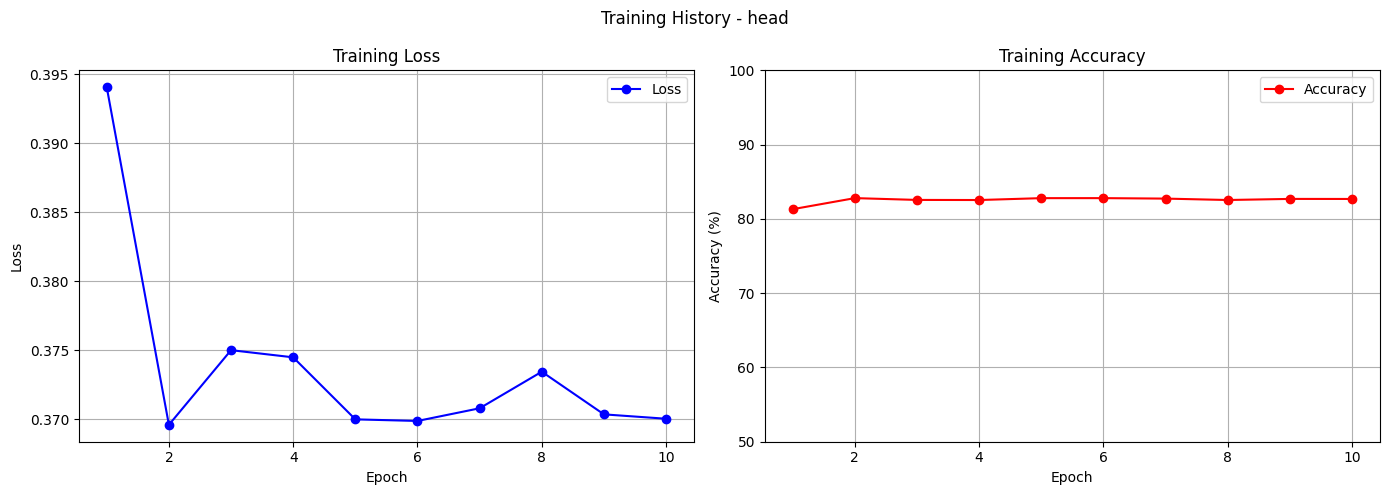

Đã save phase 1!


In [11]:
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)
model = model.to(device)

# Loss với class weight
weight_loss = torch.tensor([1.0, class_counts[0] / class_counts[1]], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weight_loss)

optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

print("=== PHASE 1: Train classifier head ===")
history_phase1 = train(model, train_loader, criterion, optimizer, epochs=10, phase="head")

torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history_phase1
}, '/kaggle/working/eff_b3_phase1.pth')
print("Đã save phase 1!")

/tmp/ipykernel_103/3972064346.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


=== PHASE 2: Fine-tune full model ===


Epoch 01/12 [full]:   0%|          | 0/2142 [00:00<?, ?it/s]/tmp/ipykernel_103/3972064346.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 01/12 [full]: 100%|██████████| 2142/2142 [23:22<00:00,  1.53it/s, loss=0.0035]


Epoch 01 | Loss: 0.0613 | Acc: 97.54%


Epoch 02/12 [full]: 100%|██████████| 2142/2142 [23:25<00:00,  1.52it/s, loss=0.0085]


...

Epoch 10 | Loss: 0.0044 | Acc: 99.85%


Epoch 11/12 [full]: 100%|██████████| 2142/2142 [23:08<00:00,  1.54it/s, loss=0.0004]


Epoch 11 | Loss: 0.0032 | Acc: 99.89%


Epoch 12/12 [full]: 100%|██████████| 2142/2142 [23:22<00:00,  1.53it/s, loss=0.0003]


Epoch 12 | Loss: 0.0041 | Acc: 99.86%


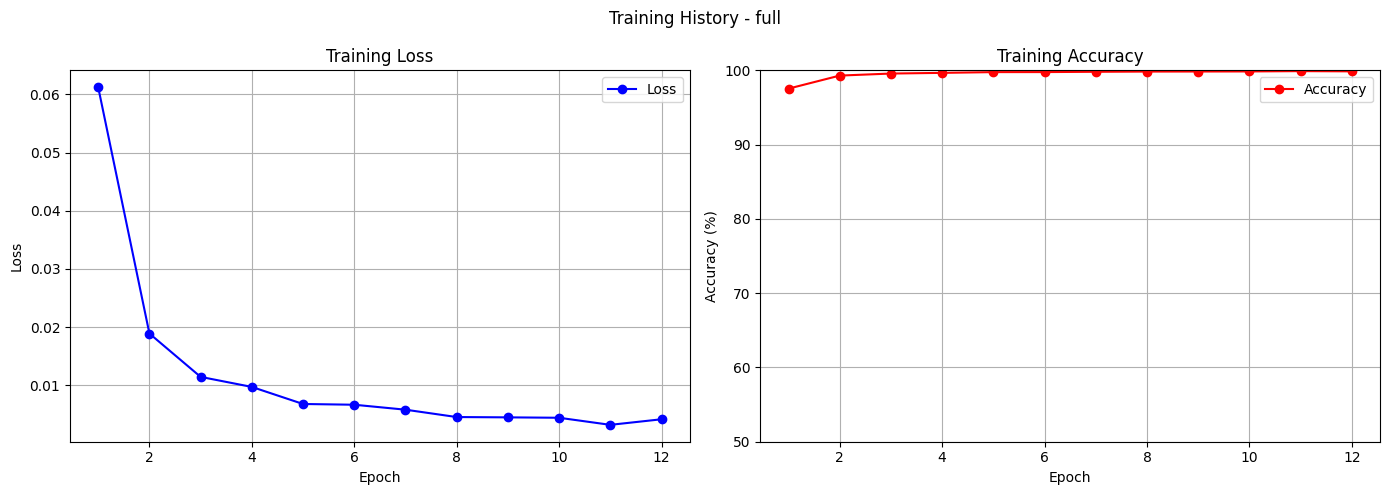

Saved final model!


In [12]:
checkpoint = torch.load('/kaggle/working/eff_b3_phase1.pth')
model.load_state_dict(checkpoint['model_state_dict'])

for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print("=== PHASE 2: Fine-tune full model ===")
train(model, train_loader, criterion, optimizer, epochs=12, phase="full")

# Save final model
torch.save(model.state_dict(), '/kaggle/working/eff_b3_final.pth')
print("Saved final model!")


=== ĐÁNH GIÁ FINAL ===


Evaluating:   0%|          | 0/1305 [00:00<?, ?it/s]/tmp/ipykernel_103/3972064346.py:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 1305/1305 [06:02<00:00,  3.60it/s]


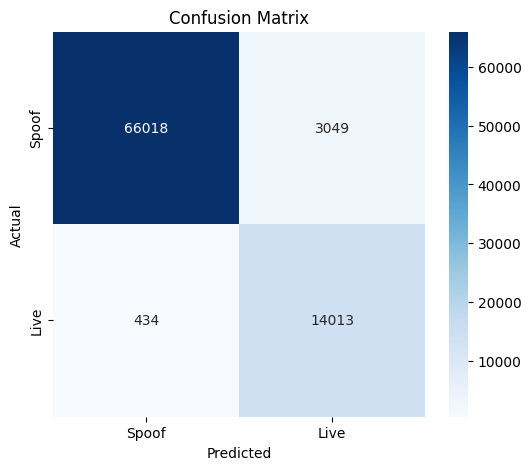

KẾT QUẢ ĐÁNH GIÁ
Accuracy  : 95.829%
Precision : 82.130%
Recall    : 96.996%
F1-Score  : 88.946%


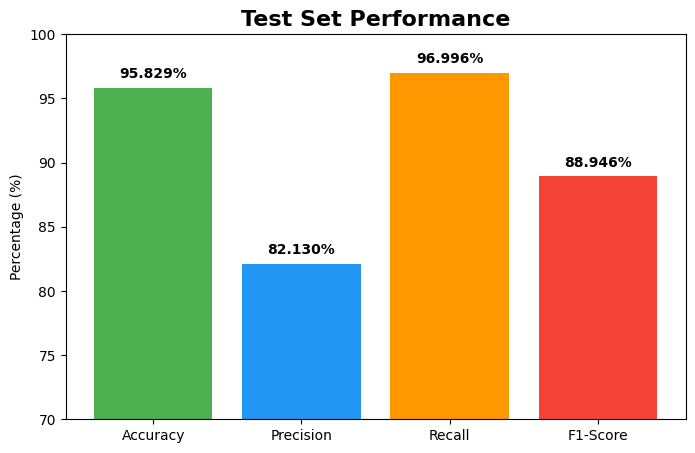

In [13]:
print("\n=== ĐÁNH GIÁ FINAL ===")
acc, prec, rec, f1 = evaluate_simple(model, test_loader)

# Plot bar
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [acc, prec, rec, f1]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, values, color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])
plt.ylim(70, 100)
plt.title('Test Set Performance', fontsize=16, fontweight='bold')
plt.ylabel('Percentage (%)')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.3f}%', ha='center', va='bottom', fontweight='bold')

plt.show()


=== ĐÁNH GIÁ FINAL ===


Evaluating:   0%|          | 0/1305 [00:00<?, ?it/s]/tmp/ipykernel_103/3972064346.py:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Evaluating: 100%|██████████| 1305/1305 [03:41<00:00,  5.90it/s]


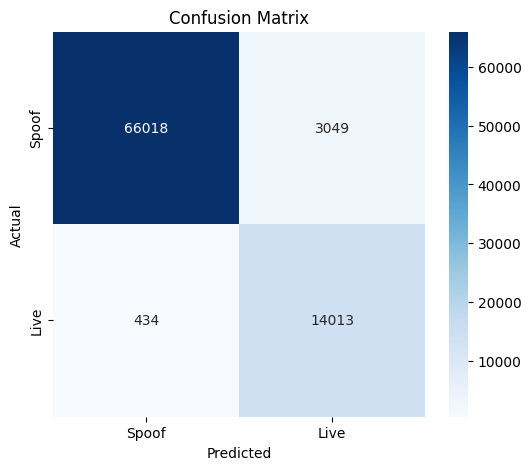

KẾT QUẢ ĐÁNH GIÁ
Accuracy  : 95.829%
Precision : 82.130%
Recall    : 96.996%
F1-Score  : 88.946%


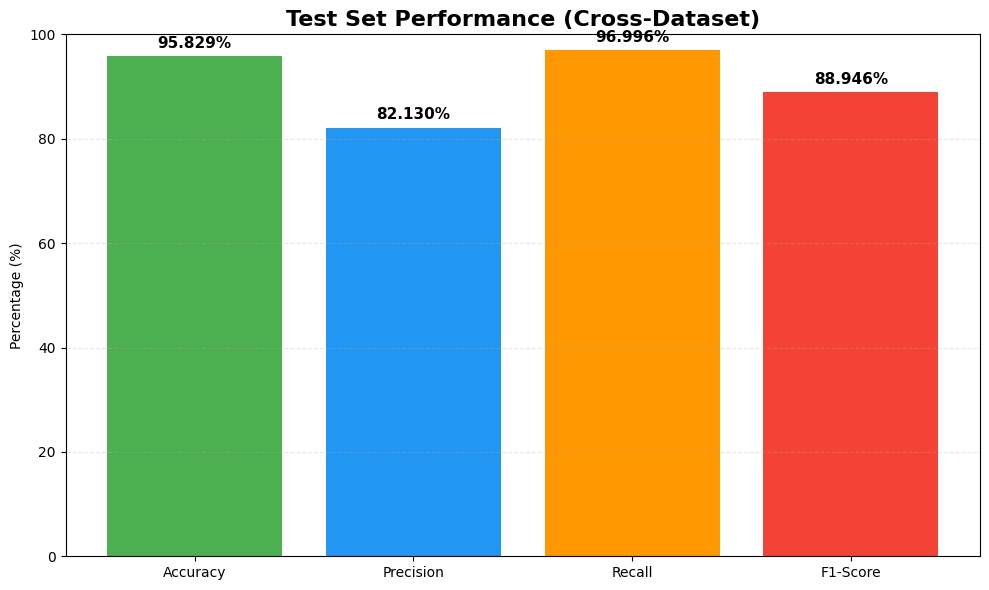

In [14]:
print("\n=== ĐÁNH GIÁ FINAL ===")
acc, prec, rec, f1 = evaluate_simple(model, test_loader)

# Plot bar - vẽ từ 0 đến 100
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [acc, prec, rec, f1]

plt.figure(figsize=(10, 6))  # tăng chiều rộng một chút cho đẹp
bars = plt.bar(metrics, values, color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])

plt.ylim(0, 100)  # <-- sửa thành từ 0 đến 100
plt.title('Test Set Performance (Cross-Dataset)', fontsize=16, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.grid(axis='y', alpha=0.3, linestyle='--')  # thêm lưới ngang nhẹ để dễ đọc

# In số trên thanh bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,  # +1 để nhãn không dính thanh
             f'{val:.3f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()